In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate, LeakyReLU, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
import albumentations as A

# Architecture des layers

Conv2D(Dimension of outspace, size of convolution window,stride lenght,
padding ('valid'=no padding/'same'=padding))

In [2]:
def build_simple_yolo(input_shape=(416, 416, 3), grid_size=5, num_boxes=1, num_classes=1):
    inputs = Input(shape=input_shape)

    # Bloc 1
    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same')(inputs)  # 416x416x8
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 208x208x8

    # Bloc 2
    x = Conv2D(16, (3, 3), strides=(1, 1), padding='same')(x)  # 208x208x16
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 104x104x16

    # Bloc 3
    x = Conv2D(16, (3, 3), strides=(1, 1), padding='same')(x)  # 104x104x16
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 52x52x16

    # Bloc 4 (réduction drastique pour limiter les paramètres)
    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same')(x)  # 52x52x8
    x = LeakyReLU(alpha=0.1)(x)
    x = MaxPooling2D(2, 2)(x)  # 26x26x8

    # Couche finale pour la grille 5x5
    outputs = Conv2D(5, (1, 1), strides=(6, 6), padding='same', activation='sigmoid')(x)  # 5x5x5

  

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [3]:
#model simpliste
model_5k = build_simple_yolo(input_shape=(416, 416, 3), grid_size=5, num_boxes=1, num_classes=1)
model_5k.summary()

c:\Users\Administrateur\Documents\courss\sem1\nafml\project_naml\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 416, 416, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 416, 416, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 416, 416, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 208, 208, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 208, 208, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 208, 208, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 104, 104, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 104, 104, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 104, 104, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 52, 52, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 52, 52, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 5)        │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,917 (19.21 KB)

 Trainable params: 4,917 (19.21 KB)

 Non-trainable params: 0 (0.00 B)

# Prétraitement des données :

Utilise cv2 ou PIL pour charger les images.
Parse les fichiers .txt YOLO pour extraire les coordonnées des boxes (normalisées entre 0 et 1).
Convertis les annotations en tenseurs compatibles avec Keras (ex: (x_center, y_center, width, height, class_id)).


In [4]:

def parse_yolo_annotation(annotation_path):
    """ On créé des listes a partir des .txt des boxes"""
    with open(annotation_path, 'r') as f:
        lines = f.readlines()
    boxes = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        boxes.append([x_center, y_center, width, height, class_id])
    return boxes

In [5]:
def yolo_to_xyxy(box):
    """les données de bases sont en format YOLO (x_center, y_center, width, height) et on les convertit en format (x_min, y_min, x_max, y_max) pour l'affichage et les calculs de métriques"""

    x_center, y_center, width, height,confidence= box

    x_min = (x_center - width / 2) 
    y_min = (y_center - height / 2)
    x_max = (x_center + width / 2)
    y_max = (y_center + height / 2)

    confidence=1.0
    return [x_min, y_min, x_max, y_max, confidence]

In [6]:
def coco_to_xyxy(box):
    """Convertit les coordonnées d'une boîte de format COCO (x_min, y_min, width, height) en format (x_min, y_min, x_max, y_max)"""
    x_min, y_min, width, height = box
    x_max = x_min + width
    y_max = y_min + height
    return [x_min, y_min, x_max, y_max, 1]

In [7]:
def yolo_to_coco_L(box):
    """Convertit les coordonnées d'une boîte de format YOLO (x_center, y_center, width, height,confidence) en format COCO (x_min, y_min, width, height) DENORMALISEES"""
    x_center, y_center, width, height ,_= box
    
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    if x_min < 0:
        x_min = 0
    elif x_min + width > 1:
        width = 1 - x_min
    if y_min < 0:
        y_min = 0
    elif y_min + height > 1:
        height = 1 - y_min
    return [x_min*416, y_min*416, width*416, height*416]

In [ ]:
#DATA AUGMENTATION 

# Définir la transformation
rotate_bright = A.Compose([
    A.Rotate(limit=(0, 360), p=1.0), 
], bbox_params=A.BboxParams(format='coco', min_visibility=0.3))


flip_it = A.Compose([
    A.HorizontalFlip(p=1.0)],
      bbox_params=A.BboxParams(format='coco'))


def augment_image(image, bboxes,facteur=10):
    """Pour chaque image et box on renvoie une liste de 100 images/box augmentées"""
    augmented_images = []
  
    for _ in range(facteur//2):  #  rotations, flipées donc * images
            
            augmented = rotate_bright(image=image, bboxes=bboxes)
      
            augmented_images.append({
                'image': augmented['image'],
                'bboxes': augmented['bboxes'],

            })
            if facteur>2:
                flip_image = flip_it(image=augmented['image'], bboxes=augmented['bboxes'])
                augmented_images.append({
                'image': flip_image['image'],   
                'bboxes': flip_image['bboxes'],
            })
        
    return augmented_images

In [16]:
BOX_COLOR = (255, 0, 0)  # Red
TEXT_COLOR = (255, 255, 255)  # White
def visualize_bbox(img, bbox, class_name, color=BOX_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, w, h = bbox
    x_min, x_max, y_min, y_max = x_min, x_max, y_min, y_max = int(x_min), int(x_min + w), int(y_min), int(y_min + h)

    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), BOX_COLOR, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img


def visualize(image, bboxes, category_ids, category_id_to_name):
    img = image.copy()
    for bbox, category_id in zip(bboxes, category_ids):
        class_name = category_id_to_name[category_id]
        img = visualize_bbox(img, bbox, class_name)
    plt.figure(figsize=(12, 12))
    plt.axis("off")
    plt.imshow(img)

In [12]:


def load_and_resize_image(img_path, target_size=(416, 416)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Optionnel : conversion RGB
    img = cv2.resize(img, target_size)  # Redimensionnement
    return img

def load_dataset(images_dir, labels_dir,limit=None):


    image_paths = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.jpg')]
    data = []
    l=0
    for img_path in image_paths:
        if l%100==0:  # Afficher le pourcentage toutes les 100 images
            print(f"Processing...{round(l*100/len(image_paths),2)} %")
        if limit is not None and l >= limit:
            break
        l += 1

        # Chemin de l'annotation correspondante
        label_path = os.path.join(labels_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
        if not os.path.exists(label_path):
            continue  # Ignore si pas d'annotation

        # Charger l'imag

        img=load_and_resize_image(img_path, target_size=(416, 416))
        #normaliser les pixels de l'image en divisant par 255
        img = img / 255.0
        img_height, img_width = img.shape[:2]

        # Parse les annotations
        boxes = parse_yolo_annotation(label_path)
        #adapte boxes a coco 
    
        boxes_coco = [yolo_to_coco_L(box) for box in boxes]
        #print(boxes_coco)
        augmented_data = augment_image(img, boxes_coco)
      

        for aug in augmented_data:
            boxes=aug['bboxes']
           
            converted_boxes = [coco_to_xyxy(box) for box in boxes]
            img=aug['image']
        # transformer les converted_boxes au format 3*3*5 de la sortie du modèle
            converted_boxes = np.array(converted_boxes)
   
            y_box = np.zeros((5, 5, 5))

            for box in converted_boxes:
                x_min,y_min, x_max, y_max, confidence = box
                x_min, y_min, x_max, y_max = x_min / 416, y_min /416, x_max / 416, y_max /416
                grid_x = int((x_min+x_max)/2 * 5)
                grid_y = int((y_min+y_max)/2 * 5)

                y_box[grid_y, grid_x] = [x_min, y_min, x_max, y_max, confidence]

 
            data.append({
                'image': img,
                'boxes': np.array(y_box),
                'image_path': img_path
            })
    return data



In [13]:
#1360images dans le dataset # apres augmentation 1.36k*facteur

images_dir = "C:/Users/Administrateur/Documents/courss/sem1/nafml/project_naml/drone_dataset_yolo/toy_dataset/imgs/"
labels_dir = "C:/Users/Administrateur/Documents/courss/sem1/nafml/project_naml/drone_dataset_yolo/toy_dataset/boxes/"
dataset = load_dataset(images_dir, labels_dir) # dt = nombre de drones total, dr = nombre de drones reperables via la grid

Processing...0.0 %
Processing...7.36 %
Processing...14.72 %
Processing...22.08 %
Processing...29.43 %
Processing...36.79 %
Processing...44.15 %
Processing...51.51 %
Processing...58.87 %
Processing...66.23 %
Processing...73.58 %
Processing...80.94 %
Processing...88.3 %
Processing...95.66 %


In [14]:
seed= 42
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=seed) # 80% entrainement
train_dataset, val_dataset = train_test_split(train_dataset, test_size=0.25, random_state=seed) # 20% validation, 60% entrainement

In [15]:
X_train = np.array([item['image'] for item in train_dataset])
y_train = np.array([item['boxes'] for item in train_dataset])

X_val = np.array([item['image'] for item in val_dataset])
y_val = np.array([item['boxes'] for item in val_dataset])

X_test = np.array([item['image'] for item in test_dataset])
y_test = np.array([item['boxes'] for item in test_dataset])

## test 

In [17]:
T=416 #taille des images
i=75

sample = X_train[i] #  image chargée
box = y_train[i] #  box chargée
if dataset:
    print(f"Nombre de bounding boxes: {np.sum((box[:,:,-1]))}")

def draw_boxes(image, grid):
    img_copy = image.copy()
    for boxes in grid:
        for box in boxes:
         
            if box[-1] == 0:  # Si la confiance est 0, on ignore
                continue
            x_min, y_min, x_max, y_max, confidence =  box*T
            cv2.rectangle(img_copy, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)
            cv2.putText(img_copy, f"Drone", (int(x_min), int(y_min)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img_copy

# Affiche la première image avec ses boxes
if dataset:
    img_with_boxes = draw_boxes(sample, box)
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)  # Pour Matplotlib
    plt.imshow(img_rgb)
    plt.axis('off')
    # Draw vertical lines for 5x5 grid
    for i in range(1, 5):
        plt.axvline(x=i * 416 / 5, color='red', linewidth=2)

# Draw horizontal lines for 5x5 grid
    for i in range(1, 5):
        plt.axhline(y=i * 416 / 5, color='red', linewidth=2)
    plt.show()

Nombre de bounding boxes: 1.0


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0xb1d3297b::Set<3,4,-1>,struct cv::impl::A0xb1d3297b::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 6 (CV_64F)


# entrainement

## Definition de la loss

In [ ]:
def yolo_loss(lambda_coord=1, lambda_noobj=0.5):

    def loss(y_true, y_pred):

        # coordonnées
        pred_xywh = y_pred[..., 0:4]
        true_xywh = y_true[..., 0:4]

        # confiance
        pred_conf = y_pred[..., 4]
        true_conf = y_true[..., 4]

        # masque objet
        obj_mask = true_conf
        noobj_mask = 1 - obj_mask

        # loss coordonnées
        coord_loss = lambda_coord * tf.reduce_mean(
            obj_mask[..., None] * tf.square(true_xywh - pred_xywh)
        )

        # Loss confiance pour objets (Binary Cross-Entropy)
        
        conf_obj_loss = tf.reduce_mean(
            tf.reshape(obj_mask, (-1, 1)) * tf.keras.losses.binary_crossentropy(tf.reshape(true_conf, (-1, 1)), tf.reshape(pred_conf, (-1, 1)), from_logits=False)
        )

        # Loss confiance pour non-objets (Binary Cross-Entropy)
        conf_noobj_loss = lambda_noobj * tf.reduce_mean(
            tf.reshape(noobj_mask, (-1, 1)) * tf.keras.losses.binary_crossentropy(tf.reshape(true_conf, (-1, 1)), tf.reshape(pred_conf, (-1, 1)), from_logits=False)
        )

        return coord_loss + conf_obj_loss + conf_noobj_loss

    return loss

## Entrainement avec loss

In [19]:
#A CHAQUE FOIS QU4ON ENTRAINE LE MODELE, ON RECREE UN NOUVEAU MODELE POUR RECOMMENCER LENTRAINEMENT A ZERO
model_5k = build_simple_yolo(input_shape=(416, 416, 3), grid_size=5, num_boxes=1, num_classes=1)
model_5k.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 416, 416, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 416, 416, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 416, 416, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 208, 208, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 208, 208, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 208, 208, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 104, 104, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 104, 104, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 104, 104, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 52, 52, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 52, 52, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 5)        │            45 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,917 (19.21 KB)

 Trainable params: 4,917 (19.21 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_5k.compile(optimizer='adam', loss=yolo_loss())  

In [21]:
len(X_train),len(y_train)

(815, 815)

In [22]:
history = model_5k.fit(
    X_train,y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.1271 - val_loss: 0.0901
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 497ms/step - loss: 0.0769 - val_loss: 0.0696
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 482ms/step - loss: 0.0622 - val_loss: 0.0567
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 467ms/step - loss: 0.0525 - val_loss: 0.0528
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 458ms/step - loss: 0.0500 - val_loss: 0.0508
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 453ms/step - loss: 0.0484 - val_loss: 0.0501
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 476ms/step - loss: 0.0474 - val_loss: 0.0489
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 495ms/step - loss: 0.0468 - val_loss: 0.0484
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 478ms/step - loss: 0.0462 - val_loss: 0.0479
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 494ms/step - loss: 0.0457 - val_loss: 0.0477
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 479ms/step - loss: 0.0451 - val_loss: 0.0479
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 4

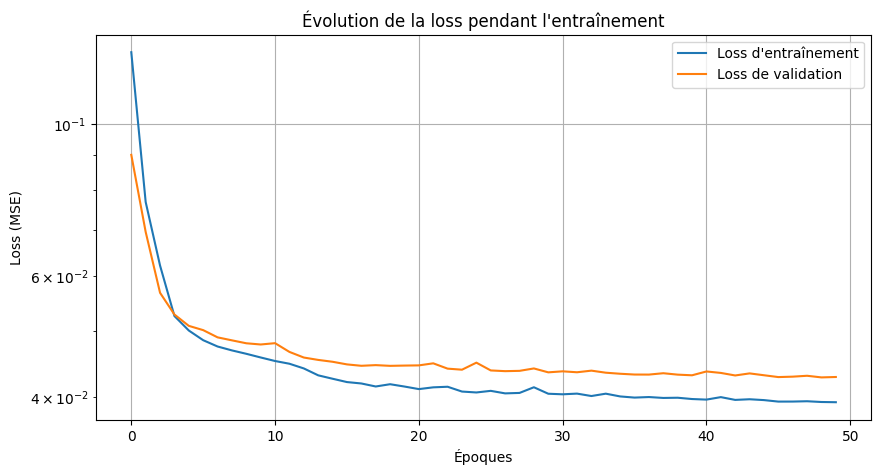

In [23]:
# Tracé de la loss
plt.figure(figsize=(10, 5))
plt.semilogy(history.history['loss'], label='Loss d\'entraînement')
plt.semilogy(history.history['val_loss'], label='Loss de validation')
plt.title('Évolution de la loss pendant l\'entraînement')
plt.xlabel('Époques')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()

Exemples du set d'entrainement

## validation du treshold par le set de valdiation

$F1=2×\frac{PrecisionRappel}{Precision+Rappel}$​

Precision : qualité des prédictions positives
Rappel : capacité à reperer les vrais positifs

In [24]:
y_pred_val= model_5k.predict(X_val)
y_pred_val_1d = y_pred_val[:,:,:,4].reshape(-1)
y_val_1d = y_val[:,:,:,4].reshape(-1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step


In [25]:


tresholds = np.linspace(0.0, 1.0, num=100)
accuracies = np.zeros(100)
f1_scores = np.zeros(100)
sensitivity = np.zeros(100)
ppv = np.zeros(100)
i=0
for th in tresholds:
    
    #transformer 3*3*5 en 1d vector
  

    y_val_treshold = (y_pred_val_1d > th)

    sensitivity[i] = np.sum((y_val_1d == 1) & (y_val_treshold == 1)) / np.sum(y_val_1d == 1)
    if np.sum(y_val_treshold) == 0:
        ppv[i] = 0
    else:
        ppv[i] = np.sum((y_val_1d == 1) & (y_val_treshold == 1)) / np.sum(y_val_treshold == 1)
    accuracy = accuracy_score(y_val_1d, y_val_treshold)
    f1 = f1_score(y_val_1d, y_val_treshold)
    accuracies[i]=accuracy
    f1_scores[i]=f1
    i+=1    


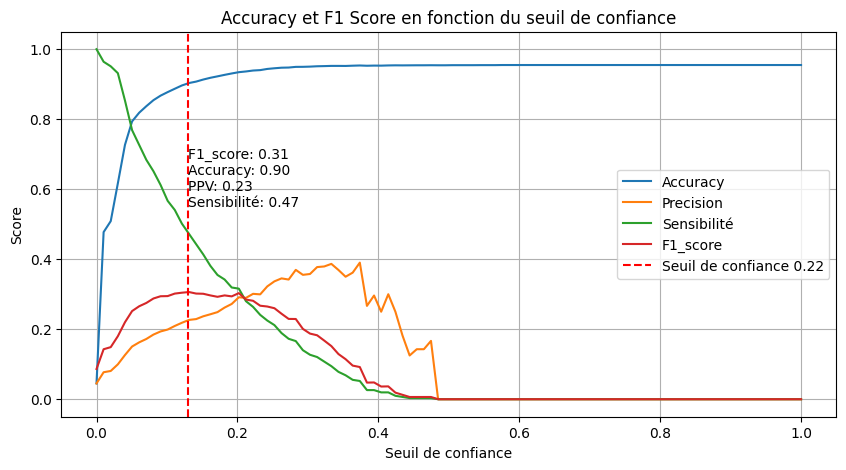

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(tresholds, accuracies, label='Accuracy')
plt.plot(tresholds, ppv, label='Precision')
plt.plot(tresholds, sensitivity, label='Sensibilité')
plt.plot(tresholds, f1_scores,label='F1_score')
plt.axvline(x=0.13, color='red', linestyle='--', label='Seuil de confiance 0.22')
plt.annotate(f'F1_score: {f1_scores[13]:.2f}\nAccuracy: {accuracies[13]:.2f}\nPPV: {ppv[13]:.2f}\nSensibilité: {sensitivity[13]:.2f}', xy=(0.13, 0.55), xytext=(0.13, 0.55))
plt.title('Accuracy et F1 Score en fonction du seuil de confiance')
plt.xlabel('Seuil de confiance')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

On chosit donc 0.22 comme seuil de confiance.

In [27]:
f1_scores

array([0.0863937 , 0.14282268, 0.14882773, 0.18004407, 0.21998321,
       0.25186766, 0.26563431, 0.27504912, 0.28776978, 0.2942097 ,
       0.29466554, 0.30181818, 0.30434783, 0.3062302 , 0.30188679,
       0.30130486, 0.29657795, 0.29261745, 0.29661017, 0.29385307,
       0.303125  , 0.28476821, 0.28125   , 0.26714801, 0.26487524,
       0.26      , 0.24421053, 0.22943723, 0.22921348, 0.20093458,
       0.1875    , 0.18271605, 0.16751269, 0.15183246, 0.12903226,
       0.11444142, 0.0960452 , 0.09195402, 0.04747774, 0.04790419,
       0.03625378, 0.03669725, 0.01880878, 0.01257862, 0.00634921,
       0.00636943, 0.00636943, 0.00638978, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [30]:
treshold_671 = 0.13

# Test du modèle 

In [31]:
y_pred_test = model_5k.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step


In [32]:
# Select a sample from the test set, e.g., the first one
sample_index = 50
sample_image = X_test[sample_index]
sample_pred = y_pred_test[sample_index]

# Function to draw predicted boxes with confidence
def draw_predicted_boxes(image, pred_boxes, threshold, T=416):
    img_copy = image.copy()
    for i in range(3):
        for j in range(3):
            confidence = pred_boxes[i, j, 4]
            if confidence > threshold:
                x_min, y_min, x_max, y_max = pred_boxes[i, j, :4] * T
                cv2.rectangle(img_copy, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (255, 0, 0), 2)  # Blue for predictions
                cv2.putText(img_copy, f"Conf: {confidence:.2f}", (int(x_min), int(y_min)-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img_copy

# Draw the image with predicted boxes
img_with_pred_boxes = draw_predicted_boxes(sample_image, sample_pred, treshold_671)
img_rgb = cv2.cvtColor(img_with_pred_boxes, cv2.COLOR_BGR2RGB)  # For Matplotlib
plt.imshow(img_rgb)
plt.axis('off')
# Draw vertical lines for 3x3 grid
for i in range(1, 3):
    plt.axvline(x=i * 416 / 3, color='red', linewidth=2)
# Draw horizontal lines for 3x3 grid
for i in range(1, 3):
    plt.axhline(y=i * 416 / 3, color='red', linewidth=2)
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0xb1d3297b::Set<3,4,-1>,struct cv::impl::A0xb1d3297b::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 6 (CV_64F)


# Metrics results 

## Detection independantly of boxes

The most important for us is to reduce the false negative. We want a high sensititvity. Most of the bounding boxes are empty so the accuracy scores is not really interesting.

In [33]:
treshold_671 = 0.13

In [34]:
sens= np.sum(((y_pred_test[...,4].reshape(-1)>treshold_671) == 1) & (y_test[...,4].reshape(-1) == 1)) / np.sum(y_test[...,4].reshape(-1) == 1)
ppv = np.sum(((y_pred_test[...,4].reshape(-1)>treshold_671) == 1) & (y_test[...,4].reshape(-1) == 1)) / np.sum(y_pred_test[...,4].reshape(-1) > treshold_671)
print(f"The sensitivity of the toy model is {sens*100:.2f}% among the test set drones")
print(f"The positive predictive value of the toy model is {ppv*100:.2f}% among the test set drones")

The sensitivity of the toy model is 42.57% among the test set drones
The positive predictive value of the toy model is 19.00% among the test set drones


## Bounding boxes prediction (calculer uniquement dans le cas de detection réussie)

We will use the same metric as in the study and a widely spread metric : Complete IoU

In [35]:
def CIoU(box1, box2):
    # box format: [x_min, y_min, x_max, y_max]
    x_min1, y_min1, x_max1, y_max1,_ = box1 #true box
    x_min2, y_min2, x_max2, y_max2,_ = box2 #predicted box

    # Calculate intersection
    inter_x_min = max(x_min1, x_min2)
    inter_y_min = max(y_min1, y_min2)
    inter_x_max = min(x_max1, x_max2)
    inter_y_max = min(y_max1, y_max2)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

    # Calculate union
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)
    union_area = area1 + area2 - inter_area

    if union_area == 0:
        iou = 0.0  # Éviter la division par zéro
    else :
        iou = inter_area / union_area

    distance = ((x_min1 + x_max1)/2 - (x_min2 + x_max2)/2)**2 + ((y_min1 + y_max1)/2 - (y_min2 + y_max2)/2)**2
    diagonal_length = ((max(x_max1, x_max2) - min(x_min1, x_min2))**2 + (max(y_max1, y_max2) - min(y_min1, y_min2))**2)
    
    if diagonal_length == 0:
        distance_loss = 0.0  # Éviter la division par zéro
    else:
        distance_loss = (distance / diagonal_length)

    beta = 4/np.pi**2 * (np.arctan((x_max1 - x_min1) / (y_max1 - y_min1)) - np.arctan((x_max2 - x_min2) / (y_max2 - y_min2)))**2
    alpha = beta / (1 - iou + beta)
    aspect_loss = alpha*beta

    ciou_loss = 1 - iou + distance_loss + aspect_loss

    return ciou_loss

In [36]:

ciou_test = []
ciou_val = []
for i in range(272):
    for j in range(3):
        for k in range(3):
            b_test= y_test[i,j,k]
            b_pred= y_pred_test[i,j,k]
            b_val= y_val[i,j,k]
            b_pred_val= y_pred_val[i,j,k]
            if (b_test[4]==1) and (b_pred[4] > treshold_671):
                ciou_test.append(CIoU(b_test, b_pred))
            if (b_val[4]==1) and (b_pred_val[4] > treshold_671):
                ciou_val.append(CIoU(b_val, b_pred_val))
ciou_test = np.array(ciou_test)
ciou_val = np.array(ciou_val)

In [37]:
print(f"La Complete IoU moyenne sur le val set est de {np.mean(ciou_val):.4f}, avec une standard deviation de {np.std(ciou_val):.4f}")
print(f"La Complete IoU moyenne sur le test set est de {np.mean(ciou_test):.4f}, avec une standard deviation de {np.std(ciou_test):.4f}")


La Complete IoU moyenne sur le val set est de 0.4057, avec une standard deviation de 0.1783
La Complete IoU moyenne sur le test set est de 0.4105, avec une standard deviation de 0.1845
